#  AI Impact on Students — GPA & Burnout Prediction
# BSAI Semester 2 | Machine Learning Project
**Dataset:** AI Student Impact Dataset (50,000 students, 16 features)  
**Targets:** `Post_Semester_GPA` (Regression) · `Burnout_Risk_Level` (Classification)  
**Tools:** Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn

# Program   : BS-AI
#Course    : AI130 - Programming for AI   
# GROUP MEMBERS:
 Zainab Qasim  - 2510129

 Eeman Arif - 2510130


 Khizran Fatima - 2510154   




Import Required Libraries



In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [136]:
df = pd.read_csv('/content/ai_student_impact_dataset.csv')
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


DATA CLEANING



In [137]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [138]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [139]:
df.drop_duplicates(inplace=True)

In [140]:
df.drop('Student_ID', axis=1, inplace=True)

ENCODING CATEGORICAL VARIABLES

In [141]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

OUTLIER DETECTION & REMOVAL

In [142]:
numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original shape:", df.shape)
print("New shape:", df_clean.shape)

df = df_clean

Original shape: (50000, 15)
New shape: (46731, 15)


In [143]:
X = df.drop(['Post_Semester_GPA', 'Burnout_Risk_Level'], axis=1)
print(X.columns.tolist())

['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score']


VISUALIZATION - OUTLIERS


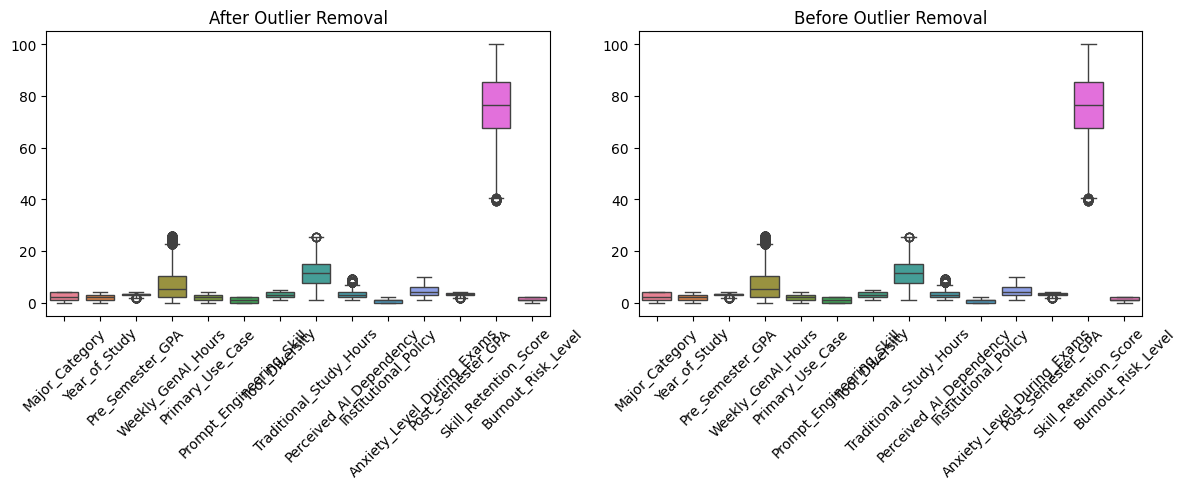

In [144]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df[numeric_cols])
plt.title("After Outlier Removal")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=df[numeric_cols])
plt.title("Before Outlier Removal")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

DATA DISTRIBUTION

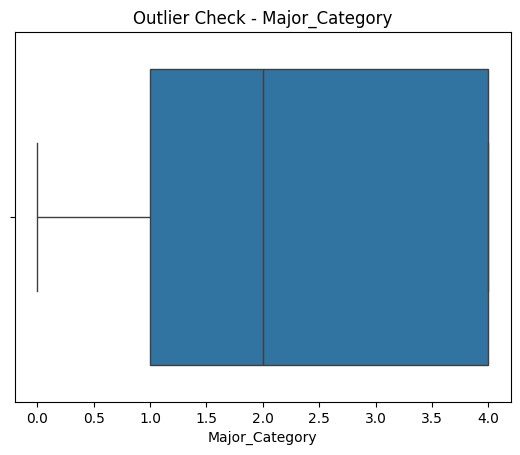

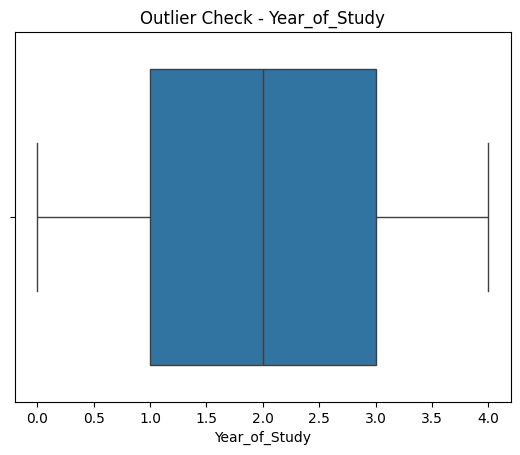

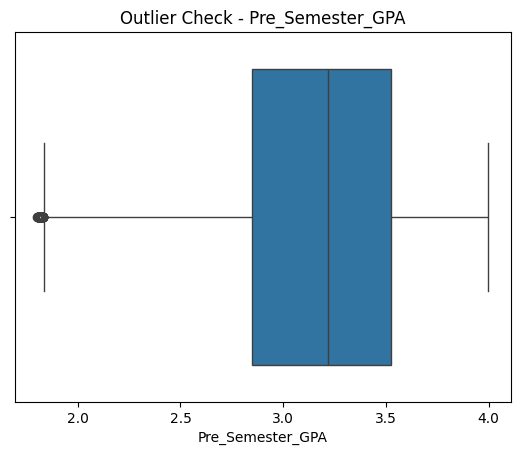

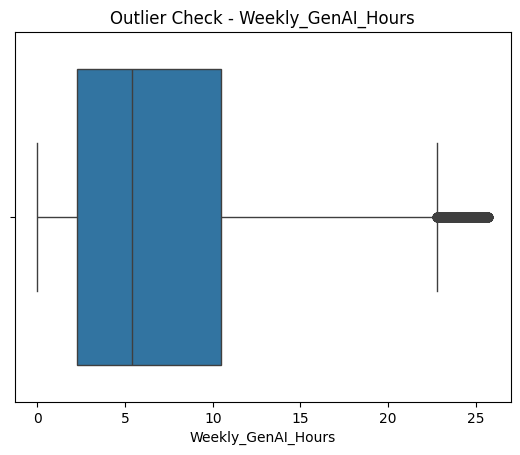

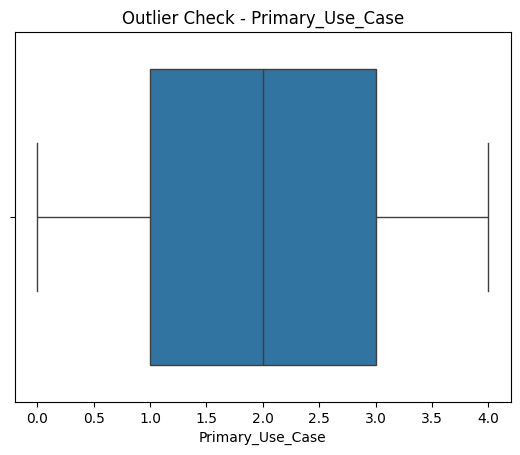

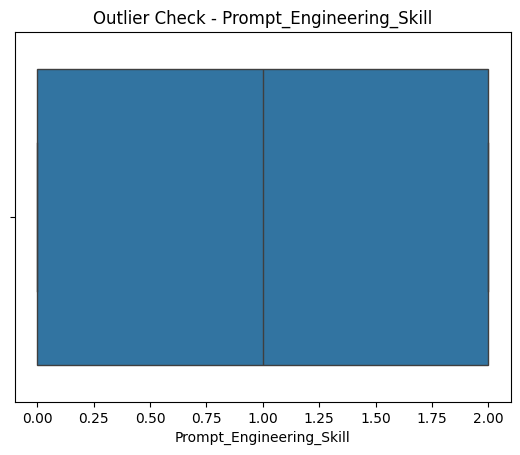

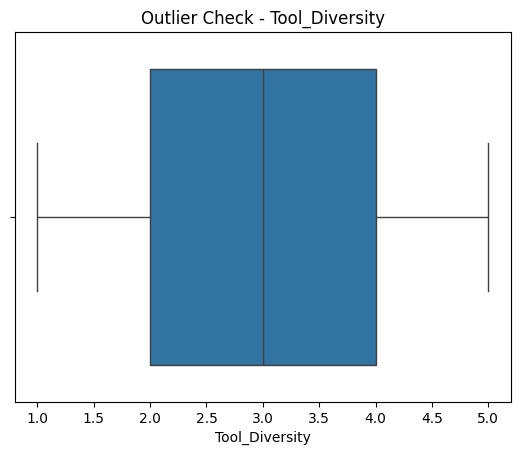

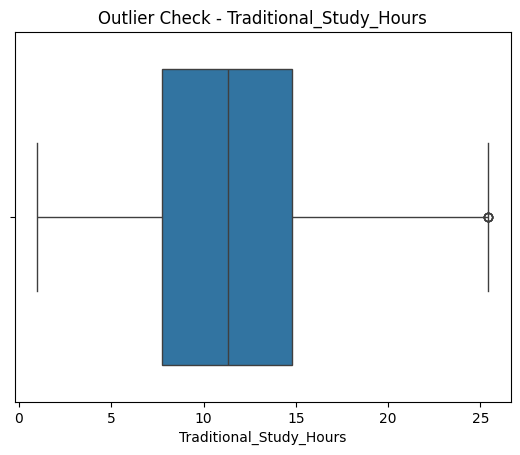

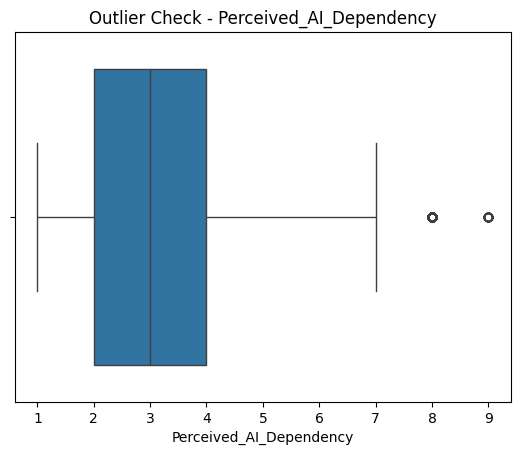

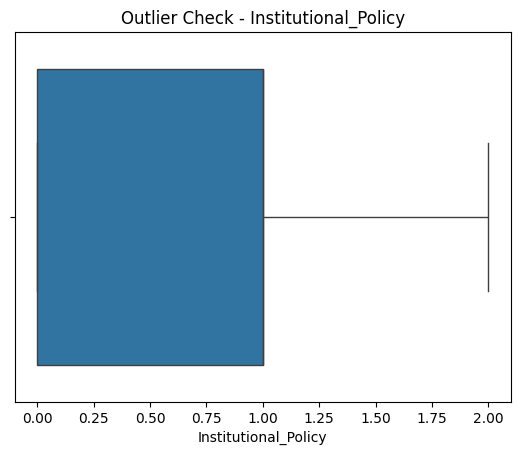

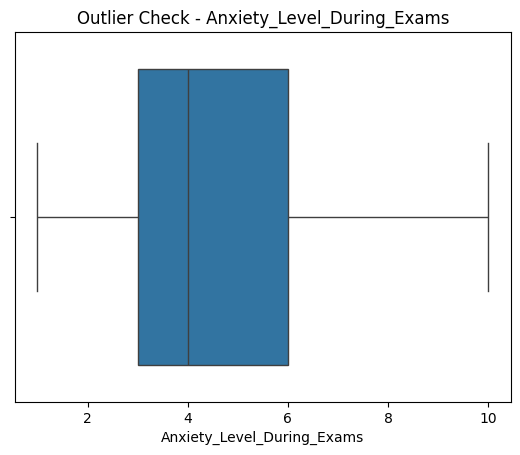

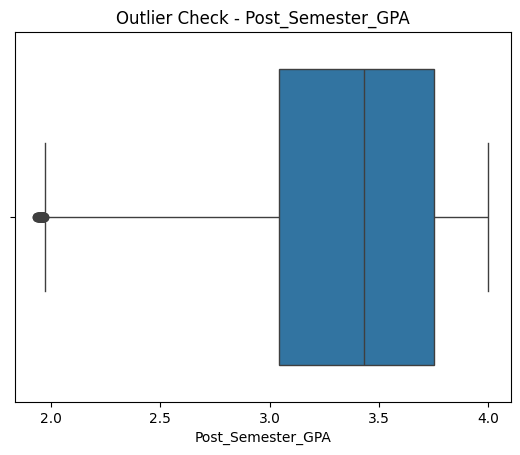

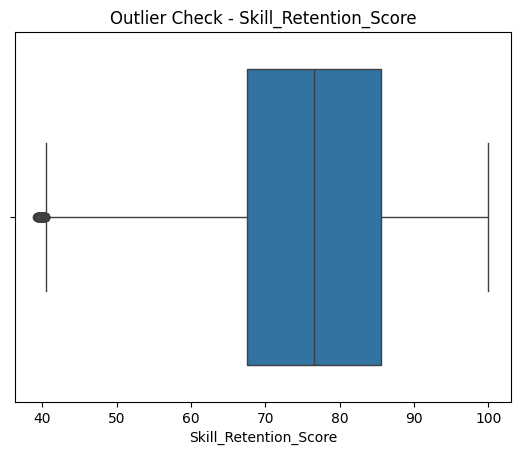

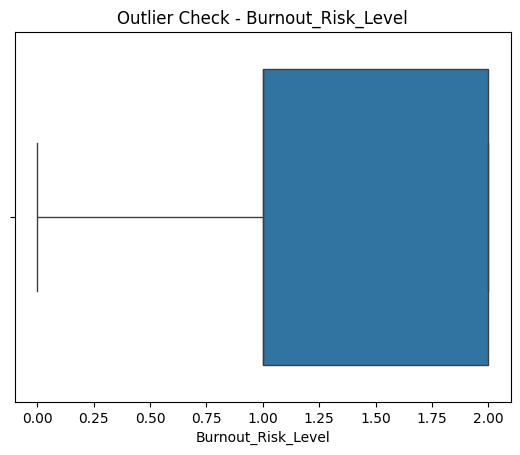

In [145]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check - {col}")
    plt.show()

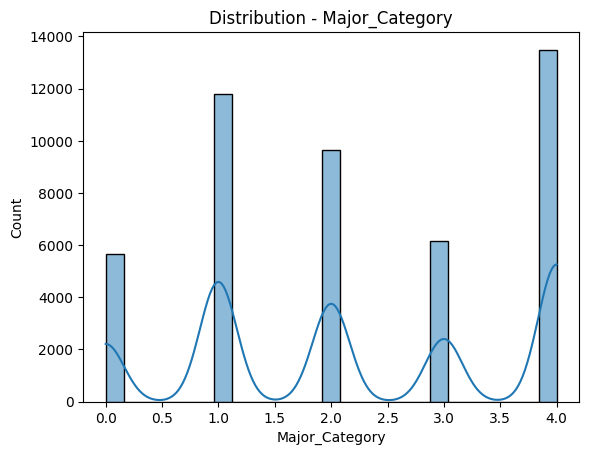

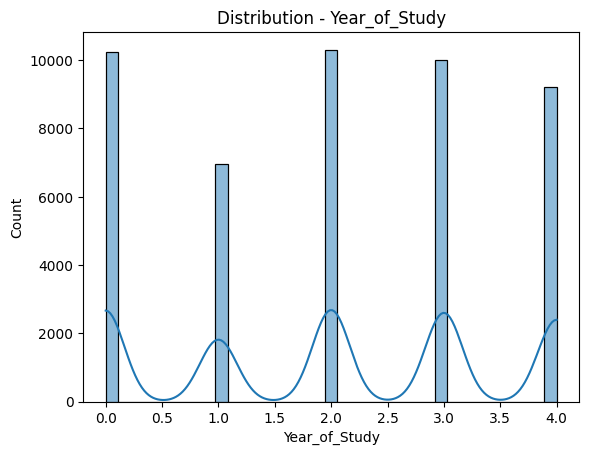

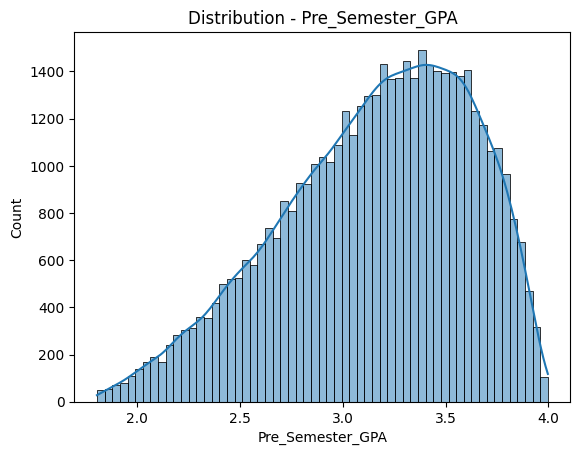

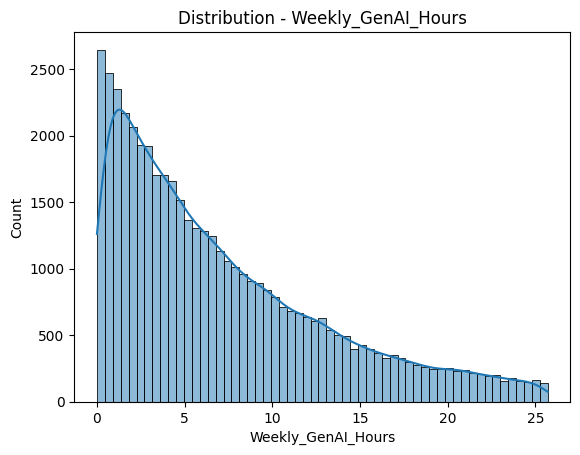

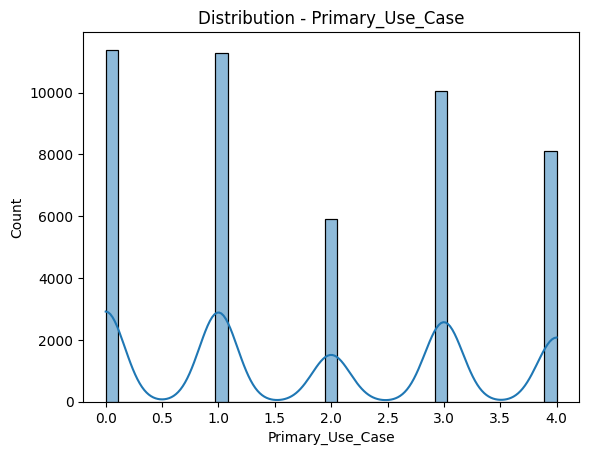

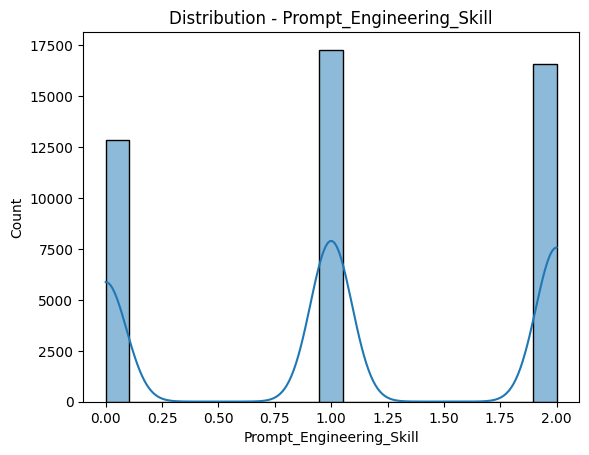

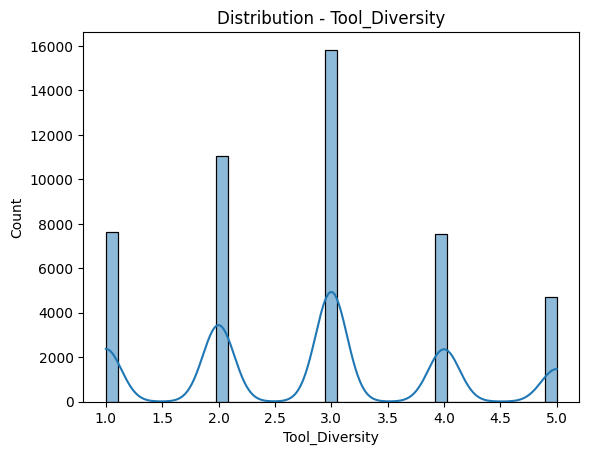

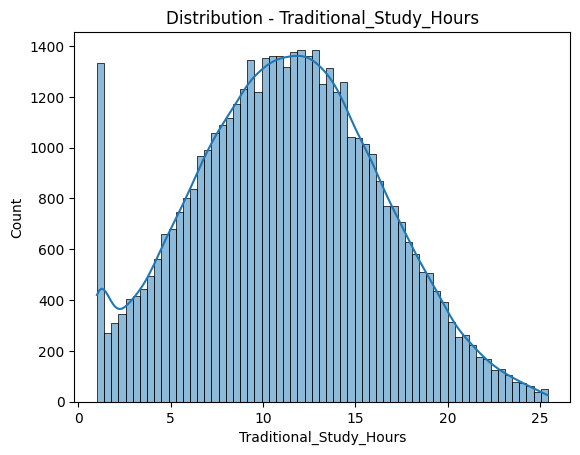

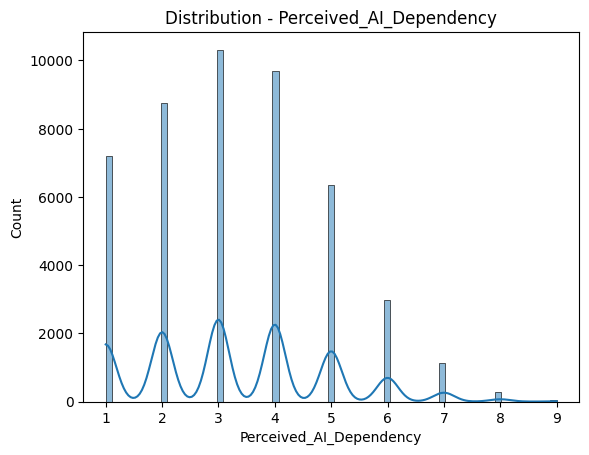

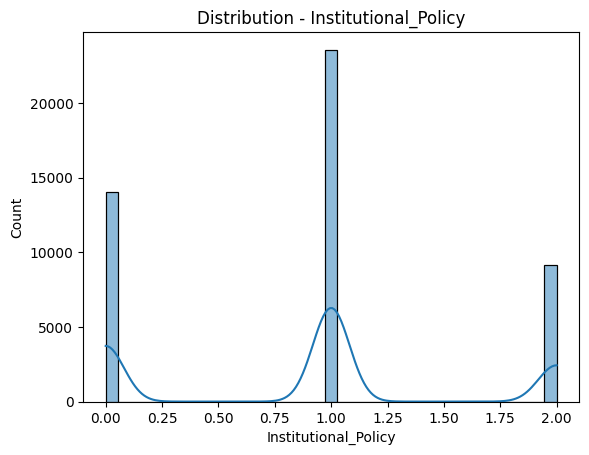

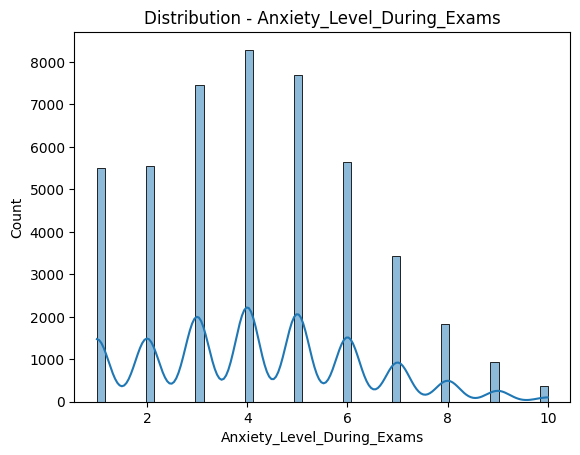

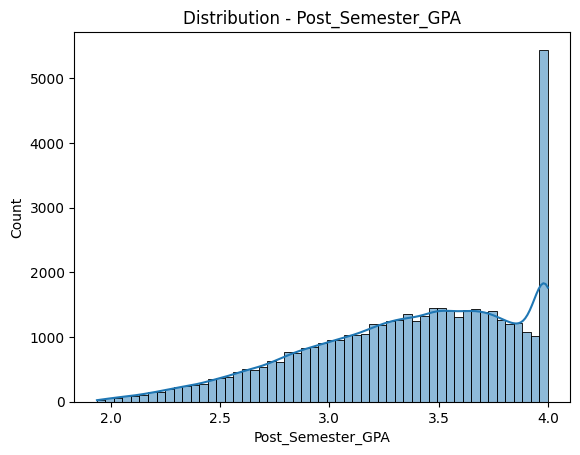

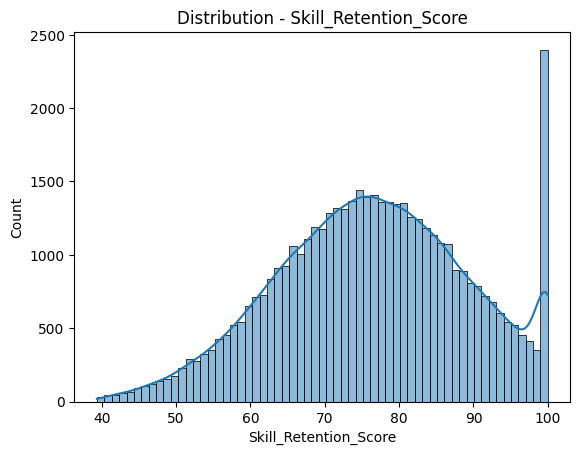

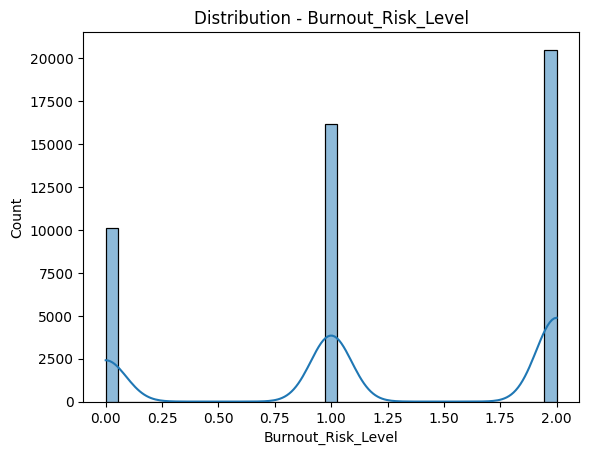

In [146]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution - {col}")
    plt.show()

FEATURE SCALING

In [147]:
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [148]:
df_scaled.to_csv('cleaned_students_data.csv', index=False)

TARGET DISTRIBUTION & ANALYSIS

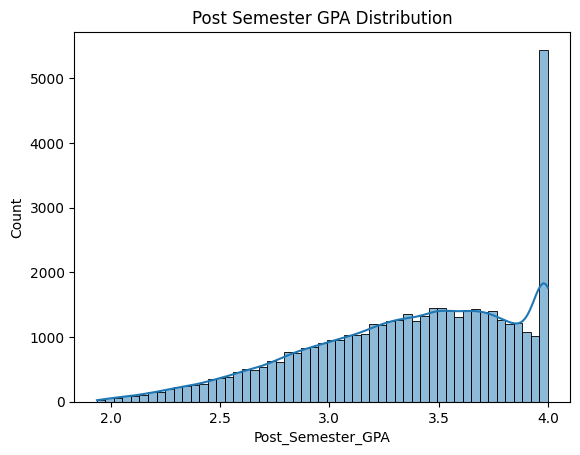

In [149]:
sns.histplot(df['Post_Semester_GPA'], kde=True)
plt.title("Post Semester GPA Distribution")
plt.show()

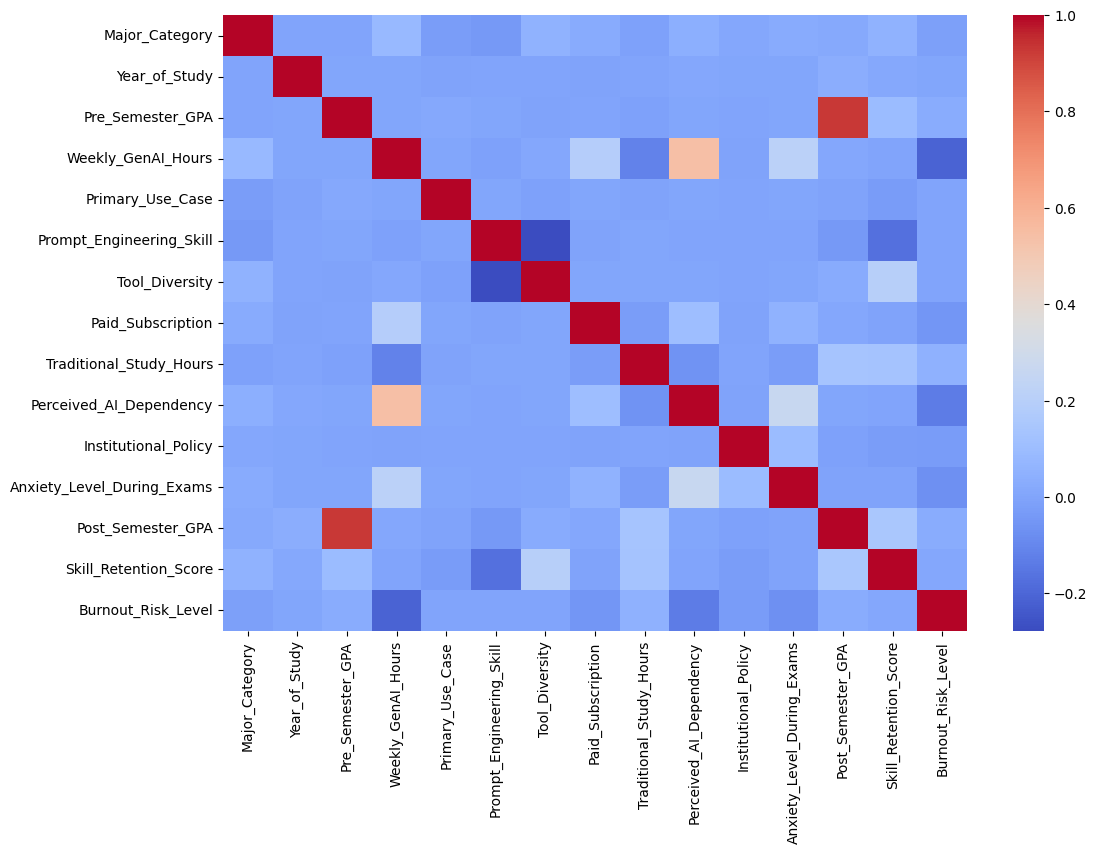

In [150]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [151]:
corr = df.corr()['Post_Semester_GPA'].sort_values(ascending=False)
print(corr)

Post_Semester_GPA             1.000000
Pre_Semester_GPA              0.925759
Skill_Retention_Score         0.150133
Traditional_Study_Hours       0.131610
Year_of_Study                 0.036481
Burnout_Risk_Level            0.030315
Tool_Diversity                0.025687
Major_Category                0.020422
Paid_Subscription             0.010576
Weekly_GenAI_Hours            0.008126
Perceived_AI_Dependency       0.003099
Primary_Use_Case             -0.005151
Anxiety_Level_During_Exams   -0.007698
Institutional_Policy         -0.011691
Prompt_Engineering_Skill     -0.043162
Name: Post_Semester_GPA, dtype: float64


FEATURE RELATIONSHIP ANALYSIS

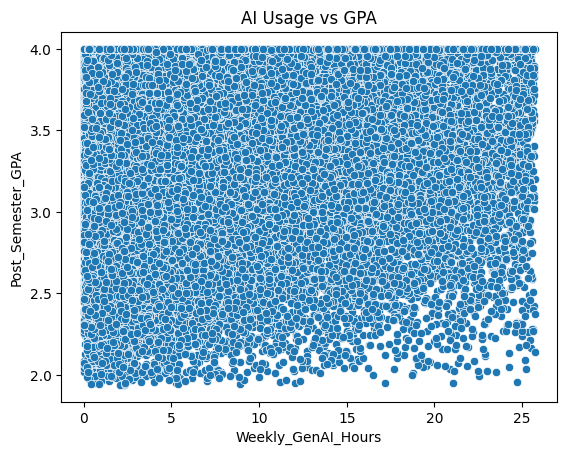

In [152]:
sns.scatterplot(x='Weekly_GenAI_Hours', y='Post_Semester_GPA', data=df)
plt.title("AI Usage vs GPA")
plt.show()

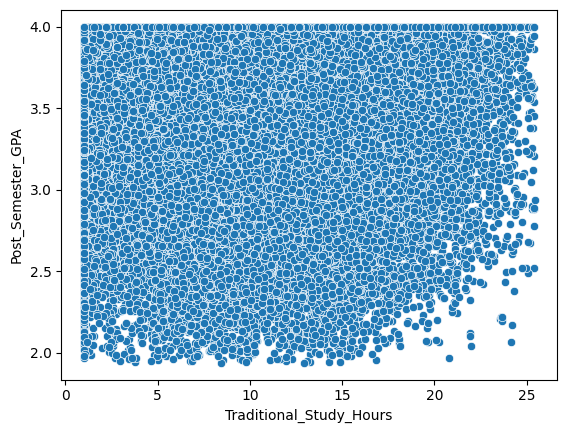

In [153]:
sns.scatterplot(x='Traditional_Study_Hours', y='Post_Semester_GPA', data=df)
plt.show()

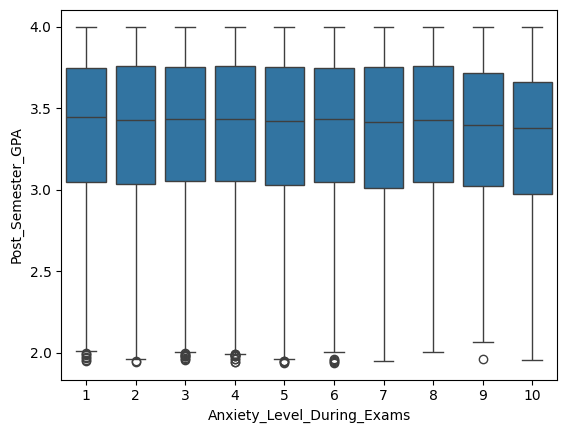

In [154]:
sns.boxplot(x='Anxiety_Level_During_Exams', y='Post_Semester_GPA', data=df)
plt.show()

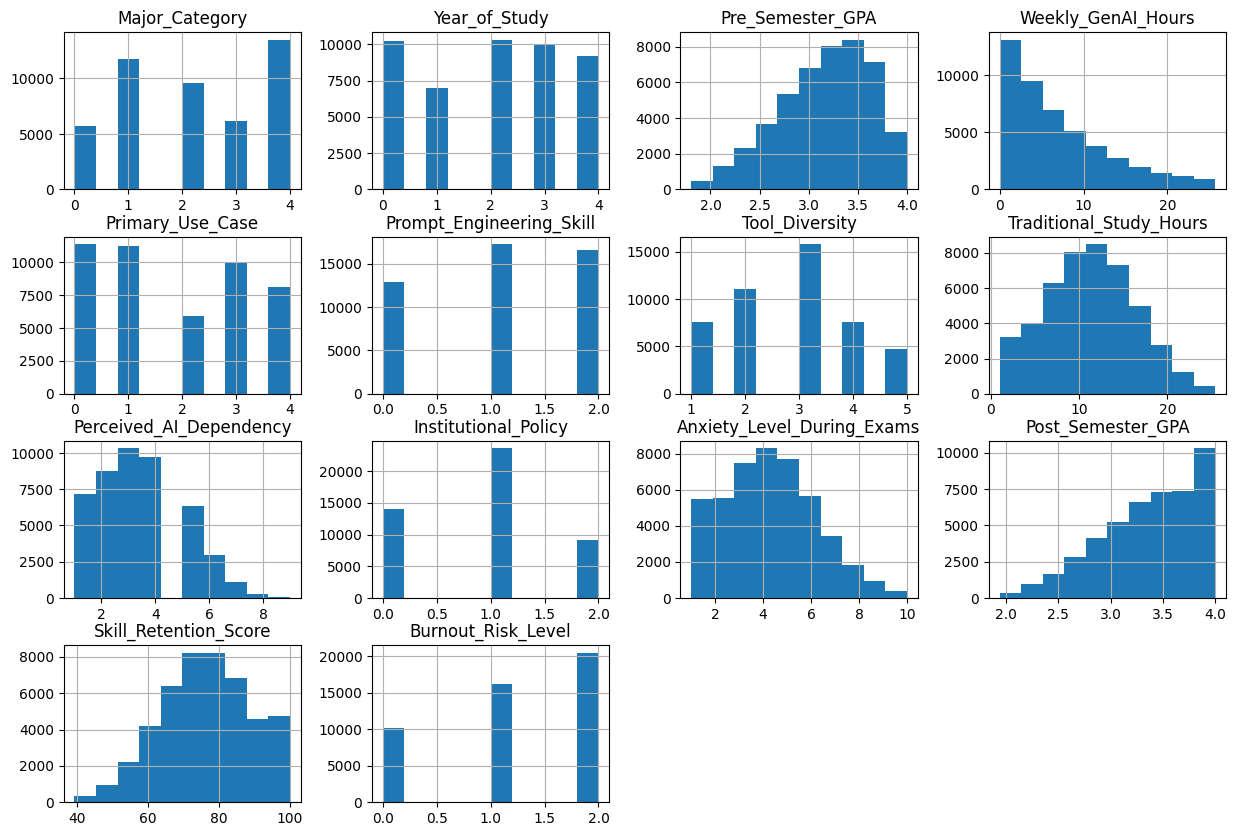

In [155]:
df.hist(figsize=(15,10))
plt.show()

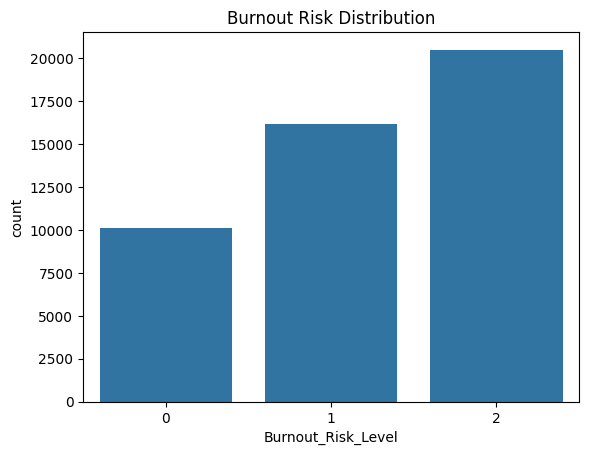

In [156]:
sns.countplot(x='Burnout_Risk_Level', data=df)
plt.title("Burnout Risk Distribution")
plt.show()

TRAIN-TEST SPLIT

In [157]:
X = df[[
    'Pre_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Anxiety_Level_During_Exams',
    'Skill_Retention_Score'
]]

y_reg = df['Post_Semester_GPA']
y_clf = df['Burnout_Risk_Level']

In [158]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

MODEL TRAINING

In [159]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

gpa_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=5,
    random_state=42
)

burnout_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    random_state=42
)

lr = LinearRegression()

In [160]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

gpa_model.fit(X_train, y_train_reg)
lr.fit(X_train, y_train_reg)
burnout_model.fit(X_train, y_train_clf)

RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)

MODEL PREDICTIONS

In [161]:
rf_pred = gpa_model.predict(X_test)
lr_pred = lr.predict(X_test)
clf_pred = burnout_model.predict(X_test)

MODEL EVALUATION

In [162]:
print("Random Forest R2:", r2_score(y_test_reg, rf_pred))
print("Linear Regression R2:", r2_score(y_test_reg, lr_pred))

Random Forest R2: 0.880403322322578
Linear Regression R2: 0.8837492779588667


In [163]:
print("Accuracy:", accuracy_score(y_test_clf, clf_pred))
print(classification_report(y_test_clf, clf_pred))

Accuracy: 0.4892478870225741
              precision    recall  f1-score   support

           0       0.59      0.29      0.39      2015
           1       0.49      0.39      0.43      3154
           2       0.47      0.66      0.55      4178

    accuracy                           0.49      9347
   macro avg       0.52      0.45      0.46      9347
weighted avg       0.50      0.49      0.48      9347



VISUALIZATION OF RESULTS

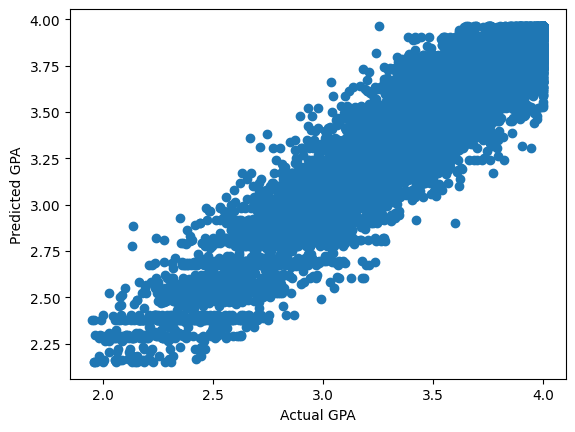

In [164]:
plt.scatter(y_test_reg, rf_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.show()

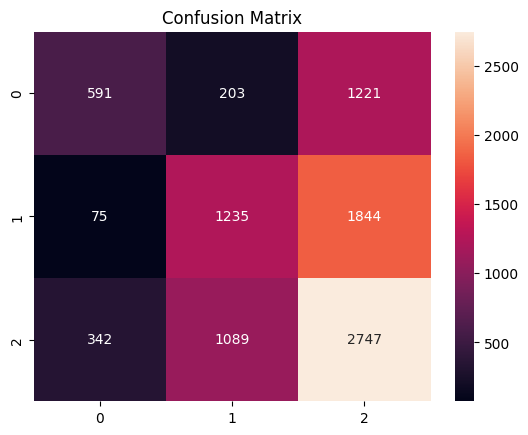

In [165]:
cm = confusion_matrix(y_test_clf, clf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

FEATURE IMPORTANCE

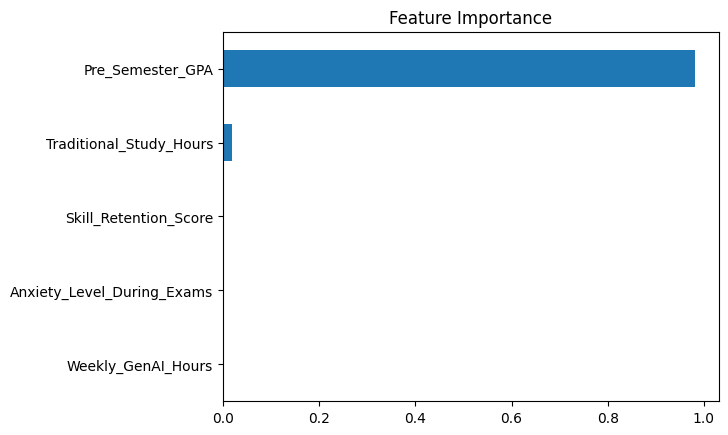

In [166]:
importance = pd.Series(
    gpa_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

SAMPLE PREDICTION

In [167]:
new_data = X.iloc[0:1]

print("Predicted GPA:", gpa_model.predict(new_data))
print("Burnout Risk:", burnout_model.predict(new_data))

Predicted GPA: [2.58116593]
Burnout Risk: [0]


 CROSS VALIDATION

In [168]:
score = cross_val_score(gpa_model, X, y_reg, cv=5)
print("Cross Validation Score:", score.mean())

Cross Validation Score: 0.874394815460853


SAVE MODELS

In [169]:
gpa_model.fit(X_train, y_train_reg)
burnout_model.fit(X_train, y_train_clf)

RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)

In [170]:
import joblib

joblib.dump(gpa_model, "gpa_model.pkl", compress=3)
joblib.dump(burnout_model, "burnout_model.pkl", compress=3)


['burnout_model.pkl']

USER INPUT PREDICTION SYSTEM

In [172]:
print("\n========== ENTER NEW STUDENT DATA ==========\n")

default_values = X.mean().to_dict()

new_student = pd.DataFrame([default_values])

pre_gpa = float(input("Pre Semester GPA: "))
weekly_ai_hours = float(input("Weekly GenAI Hours: "))
traditional_hours = float(input("Traditional Study Hours: "))
anxiety = int(input("Anxiety Level During Exams (1-10): "))
skill_retention = float(input("Skill Retention Score (0-100)High score = better understanding: "))

new_student['Pre_Semester_GPA'] = pre_gpa
new_student['Weekly_GenAI_Hours'] = weekly_ai_hours
new_student['Traditional_Study_Hours'] = traditional_hours
new_student['Anxiety_Level_During_Exams'] = anxiety
new_student['Skill_Retention_Score'] = skill_retention

new_student = new_student[X.columns]

predicted_gpa = gpa_model.predict(new_student)
predicted_burnout = burnout_model.predict(new_student)

burnout_labels = {
    0: 'High',
    1: 'Low',
    2: 'Medium'
}

print("\n========== PREDICTION RESULT ==========\n")

print("Predicted GPA:", round(predicted_gpa[0], 2))
print("Predicted Burnout Risk:", burnout_labels[int(predicted_burnout[0])])


========== ENTER NEW STUDENT DATA ==========

Pre Semester GPA: 3.4
Weekly GenAI Hours: 8
Traditional Study Hours: 8
Anxiety Level During Exams (1-10): 7
Skill Retention Score (0-100)High score = better understanding: 80

========== PREDICTION RESULT ==========

Predicted GPA: 3.53
Predicted Burnout Risk: Medium


In [173]:
import os

print("GPA model:", os.path.getsize("gpa_model.pkl") / 1024 / 1024, "MB")
print("Burnout model:", os.path.getsize("burnout_model.pkl") / 1024 / 1024, "MB")

GPA model: 0.016901016235351562 MB
Burnout model: 0.025650978088378906 MB


In [174]:
print(gpa_model.feature_names_in_)

['Pre_Semester_GPA' 'Weekly_GenAI_Hours' 'Traditional_Study_Hours'
 'Anxiety_Level_During_Exams' 'Skill_Retention_Score']


SAVE FINAL MODELS

In [175]:
import joblib

joblib.dump(gpa_model, "gpa_model.pkl")
joblib.dump(burnout_model, "burnout_model.pkl")

print("Models saved successfully.")

Models saved successfully.
